In [ ]:
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn import preprocessing
import pandas as pd
import numpy as np

In [ ]:
drive.mount("/content/drive/")
meddf = pd.read_csv('/MyDrive/medics_1.csv', decimal=',', sep=',')

NameError: name 'drive' is not defined

##подготовка данных

In [ ]:
df = meddf.copy()
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ', '_')
df.columns = df.columns.str.replace(',', '')
df['развитие_опп'] = df['развитие_опп'].where(df['развитие_опп'] != 'нет', 0)
df['развитие_опп'] = df['развитие_опп'].astype(bool)
for i in df.columns[1:]:
    if 1 in df[i].unique() and 0 in df[i].unique() and len(df[i].unique()) == 2:
        df[i] = df[i].astype(bool)

In [ ]:
numeric_columns = df.select_dtypes(include=['int64', 'float64'])
from scipy.stats import iqr, scoreatpercentile

h = 3
for i in numeric_columns:
    k = iqr(df[i])
    p = [scoreatpercentile(df[i], 25) - (k * h), scoreatpercentile(df[i], 75) + (k * h)]
    for g in range(len(df[i])):
        if df[i][g] < p[0] or df[i][g] > p[1]:
            df.loc[g, i] = np.NAN

In [ ]:
df = df.drop_duplicates()

In [ ]:
df['рн'] = df['рн'].str.replace(',', '.').astype(float)
df['чсс'] = df['чсс'].str.replace('7o', '70').astype(float)

obj_df = df.select_dtypes(include=['object']).copy()
df = pd.concat([df, pd.get_dummies(obj_df)], axis=1)
del df['хбп']
test_cols = []
for i in df.columns[df.isnull().any()]:
    test_cols.append(i)
test_df = df[df.isnull().any(axis=1)].copy()
df = df.dropna()

<ipython-input-6-356b086ee502>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['рн'] = df['рн'].str.replace(',', '.').astype(float)
<ipython-input-6-356b086ee502>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['чсс'] = df['чсс'].str.replace('7o', '70').astype(float)


In [ ]:
bad_cols = list(test_df.columns[test_df.isnull().any()])

##заполнение пропусков и выбросов катбустом

In [ ]:
!pip install catboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 7.3 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostRegressor
bad_cols = list(test_df.columns[test_df.isnull().any()])
for bads in bad_cols:
  if bads != 'триглицериды' and bads != 'лпнп':
    y = df[bads]
    X = df.loc[:, df.columns != bads]
    print(bads)
    print(X.columns)
    bad_need = test_df[test_df[bads].isna()]
    bad_need.pop(bads)
    print(bad_need.columns)
    model = CatBoostRegressor(loss_function='RMSE', depth = 6,
    learning_rate = 0.03,
    od_type = "Iter",
    od_wait = 100, iterations=1000)
    model.fit(X,y)
    predictions = model.predict(bad_need)
    test_df.loc[test_df[bads].isna(), bads] = predictions

test_df = test_df.dropna()

Выходные данные были обрезаны до нескольких последних строк (5000).
132:	learn: 3.5019343	total: 567ms	remaining: 3.7s
133:	learn: 3.4803139	total: 571ms	remaining: 3.69s
134:	learn: 3.4603926	total: 575ms	remaining: 3.68s
135:	learn: 3.4484357	total: 578ms	remaining: 3.67s
136:	learn: 3.4256911	total: 582ms	remaining: 3.67s
137:	learn: 3.4040366	total: 586ms	remaining: 3.66s
138:	learn: 3.3891922	total: 590ms	remaining: 3.65s
139:	learn: 3.3626806	total: 593ms	remaining: 3.64s
140:	learn: 3.3564947	total: 597ms	remaining: 3.64s
141:	learn: 3.3406375	total: 601ms	remaining: 3.63s
142:	learn: 3.3137865	total: 604ms	remaining: 3.62s
143:	learn: 3.2914300	total: 608ms	remaining: 3.61s
144:	learn: 3.2713052	total: 611ms	remaining: 3.6s
145:	learn: 3.2613432	total: 615ms	remaining: 3.6s
146:	learn: 3.2434015	total: 619ms	remaining: 3.59s
147:	learn: 3.2305276	total: 622ms	remaining: 3.58s
148:	learn: 3.2229002	total: 626ms	remaining: 3.58s
149:	learn: 3.2031937	total: 629ms	remaining: 3.57s

In [ ]:
df = pd.concat([df, test_df], axis=0)

In [ ]:
df = df.rename(columns = {'мочевина_':'мочевина'})
df.head()

,развитие_опп,возраст,пол,гб,сахарный_диабет,стенокардия,инфаркт_миокарда,мерцательная_аритмия,желудочковая_экстрасистолия,а-в_блокада,...,длительность_операции,длительность_аик,время_пережатия_аорты,объем_кровопотерии,объем_гемотрансфузии,объем_инфузий,диурез,хбп_Пациенты без ХБП,хбп_Стадия C1-C2,хбп_Стадия С3
3,False,62,True,True,False,True,True,True,False,False,...,210,71,43,500.0,1283,1700,1700,0,1,0
4,True,55,True,True,True,True,True,False,False,False,...,265,116,74,500.0,1560,1800,1300,0,1,0
5,False,60,True,True,False,True,True,False,True,False,...,240,74,62,200.0,1350,2100,1800,1,0,0
8,False,60,True,True,False,True,False,False,False,False,...,299,122,75,500.0,600,1050,4000,0,1,0
9,True,58,True,True,True,True,False,True,False,False,...,185,64,55,500.0,540,1200,700,0,1,0


In [ ]:
df_for_regr = df.copy()

убираем последствия одной горячей штучки

In [ ]:
df['хбп'] = 1

df.loc[df['хбп_Пациенты без ХБП'] == True, 'хбп'] = 1
df.loc[df['хбп_Стадия C1-C2'] == True, 'хбп'] = 2
df.loc[df['хбп_Стадия С3'] == True, 'хбп'] = 3
del df['хбп_Пациенты без ХБП']
del df['хбп_Стадия C1-C2']
del df['хбп_Стадия С3']

дополнительный столбец с данными по пациентам,
прооперированным с использованием АИК, которым проводилось
переливание крови

In [ ]:
df['аик_с_переливанием'] = False
df.loc[(df['аик'] == True) & (df['объем_гемотрансфузии'] != 0), 'аик_с_переливанием'] = True

In [ ]:
print(df['аик_с_переливанием'])

3       True
4       True
5       True
8       True
9       True
       ...  
182    False
184     True
188     True
192     True
195     True
Name: аик_с_переливанием, Length: 190, dtype: bool


сохраняем файл для DataLens

In [ ]:
df.to_csv('medics_final.csv')

In [ ]:
df = pd.read_csv("/content/medics_final.csv")

##процент пациентов с хроническими заболеваниям(сахарный диабет, гипертония, хроническая болезнь почек) для групп “есть ОПП/нет ОПП”

In [ ]:
df['хроническая_болезнь'] = False
df.loc[df['сахарный_диабет'] == True, 'хроническая_болезнь'] = True
df.loc[df['хбп'] != 1, 'хроническая_болезнь'] = True
df.loc[df['гб'] == True, 'хроническая_болезнь'] = True
df['хроническая_болезнь_с_опп'] = False
df['хроническая_болезнь_без_опп'] = False
df.loc[(df['хроническая_болезнь'] == True) & (df['развитие_опп'] == True), 'хроническая_болезнь_с_опп'] = True
df.loc[(df['хроническая_болезнь'] == True) & (df['развитие_опп'] == False), 'хроническая_болезнь_без_опп'] = True
chronic_disease = round((df['хроническая_болезнь_с_опп'].value_counts()[True] / df['развитие_опп'].value_counts()[True]) * 100, 2)
not_chronic_disease = round((df['хроническая_болезнь_без_опп'].value_counts()[True] / df['развитие_опп'].value_counts()[False]) * 100, 2)
print(f"Процент людей с хроническими заболеваниями с ОПП: {chronic_disease} \nПроцент людей с хроническими заболеваниями без ОПП: {not_chronic_disease}")

Процент людей с хроническими заболеваниями с ОПП: 97.48 
Процент людей с хроническими заболеваниями без ОПП: 98.59


##новый фактор на основе столбца “Индекс массы тела” и количество пациентов, имеющих проблемы с сердцем

имт

In [ ]:
df['уровень_имт'] = 'норма'
df.loc[df['имт'] >= 25, 'уровень_имт'] = 'выше нормы'

проблемы с сердцем

In [ ]:
# print(df)
df['проблемы_с_сердцем'] = False
df.loc[df['стенокардия'] == True, 'проблемы_с_сердцем'] = True
df.loc[df['инфаркт_миокарда'] == True, 'проблемы_с_сердцем'] = True
df.loc[df['мерцательная_аритмия'] == True, 'проблемы_с_сердцем'] = True
df.loc[df['желудочковая_экстрасистолия'] == True, 'проблемы_с_сердцем'] = True
df.loc[df['а-в_блокада'] == True, 'проблемы_с_сердцем'] = True
df.loc[df['блокада_ножек_пучка_гиса'] == True, 'проблемы_с_сердцем'] = True

проблемы с сердцем по группам

In [ ]:
df['проблемы_норма'] = False
df.loc[(df['проблемы_с_сердцем'] == 1) & (df['уровень_имт'] == 'норма'), 'проблемы_норма'] = True
df['проблемы_выше_нормы'] = False
df.loc[(df['проблемы_с_сердцем'] == 1) & (df['уровень_имт'] == 'выше нормы'), 'проблемы_выше_нормы'] = True
print(f"Количество людей с ИМТ в норме и проблемами с сердцем: {df['проблемы_норма'].value_counts()[True]}\nКоличество людей с ИМТ выше нормы и проблемами с сердцем: {df['проблемы_выше_нормы'].value_counts()[True]}")

Количество людей с ИМТ в норме и проблемами с сердцем: 21
Количество людей с ИМТ выше нормы и проблемами с сердцем: 168


##зависимость длительности операции от факта перенесенного инфаркта миокарда

In [ ]:
import pandas as pd


def correlation_ratio(numerical, categorical):

  values = np.array(numerical)
  ss_total = np.sum((values.mean() - values) ** 2)

  cats = np.unique(categorical, return_inverse = True)[1]

  ss_ingroups = 0

  for c in np.unique(cats):

    group = values[np.argwhere(cats == c).flatten()]
    ss_ingroups += np.sum((group.mean() - group) ** 2)

  return np.sqrt(1 - ss_ingroups/ss_total)


print(correlation_ratio(df['длительность_операции'], df['инфаркт_миокарда']))

0.01610074965354048


верно ли, что у пациентов с ИМТ выше нормы будет повышенный
уровень холестерина?

In [ ]:
df['имт_холестерин'] = False
df.loc[(df['холестерин'] > 7.8) & (df['уровень_имт'] == 'выше нормы'), 'имт_холестерин'] = True
print(df['имт_холестерин'].value_counts()[True])
print((df['имт_холестерин'].value_counts()[True] / len(df)) * 100, ' => нет')

3
1.5789473684210527  => нет


проверка на адекватность диагноза

In [ ]:
df['адекватный_диагноз'] = 1 #без хбп
df.loc[(df['скф_расч.'] >= 60) & (df['скф_расч.'] <= 97), 'адекватный_диагноз'] = 2 #стадия С1-С2
df.loc[df['скф_расч.'] < 60,'адекватный_диагноз'] = 3 #стадия С3
print((df['адекватный_диагноз'] == df['хбп']).value_counts()[True] / len(df) * 100)

57.36842105263158


верно ли, что даже без хронических болезней почек с возрастом
толщина паренхимы почек уменьшается



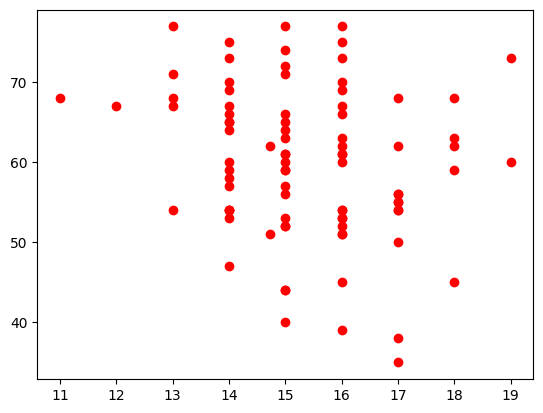

-0.18532392575239234  => нет


In [ ]:
import matplotlib.pyplot as plt


df['толщина_без_опп'] = np.NaN
df.loc[df['хбп'] == 1, 'толщина_без_опп'] = df['толщина_паренхимы_почек']
plt.plot(df['толщина_без_опп'], df['возраст'], 'ro')
plt.show()
print(df['толщина_паренхимы_почек'].corr(df['возраст']), ' => нет')

In [ ]:
corr = df.corr()
corr.style.background_gradient(cmap='magma')

<ipython-input-53-a35ccbaa0e56>:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr = df.corr()


In [ ]:
print(df['холестерин'].corr(df['развитие_опп']))

0.020032002836186658


In [ ]:
!pip install matplotlib

In [ ]:
import seaborn
import matplotlib.pyplot as plt

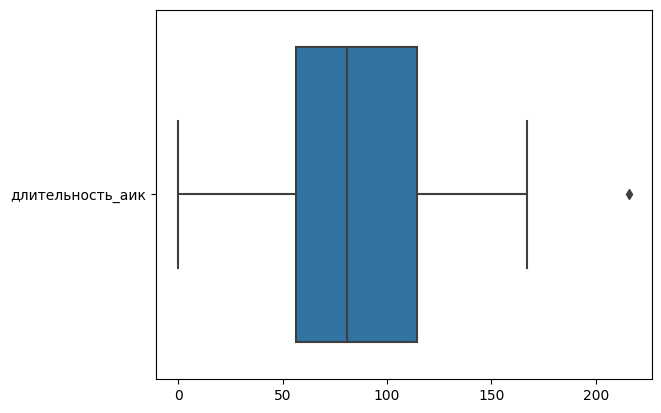

In [ ]:
df = df[df['развитие_опп'] == True]

#1
s = seaborn.boxplot(data=df[['длительность_аик']], orient='h')
plt.show()

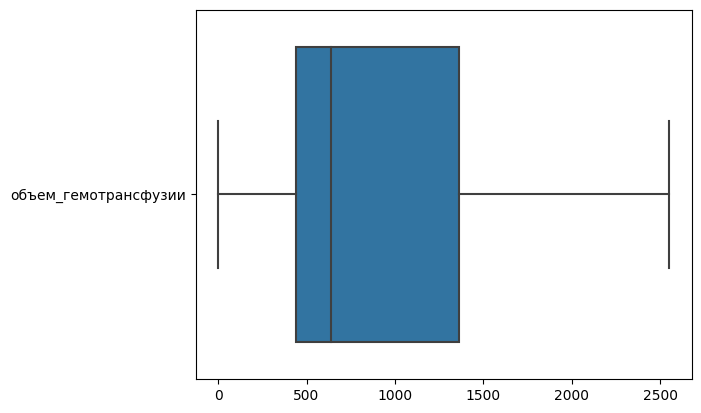

In [ ]:
# 3
s = seaborn.boxplot(data=df[['объем_гемотрансфузии']], orient='h')
plt.show()


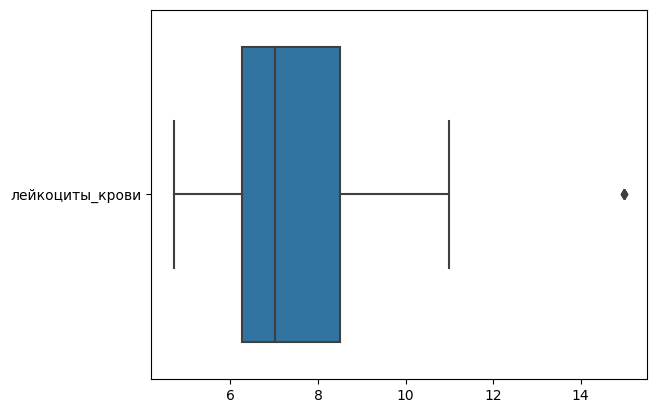

In [ ]:
#6
s = seaborn.boxplot(data=df[['лейкоциты_крови']], orient='h')
plt.show()


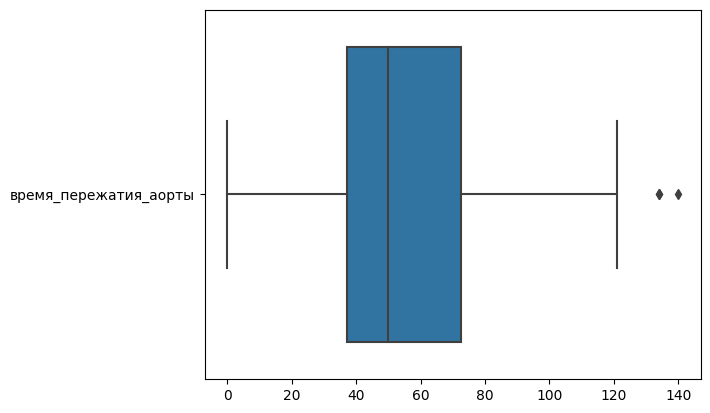

In [ ]:
#8
s = seaborn.boxplot(data=df[['время_пережатия_аорты']], orient='h')
plt.show()


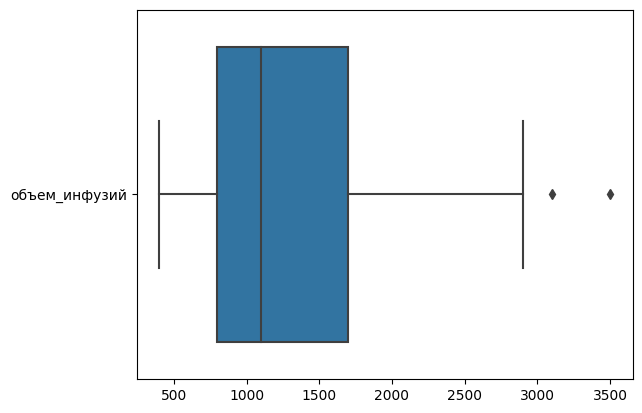

In [ ]:
#9
s = seaborn.boxplot(data=df[['объем_инфузий']], orient='h')
plt.show()

In [ ]:
df.head()

,Unnamed: 0,развитие_опп,возраст,пол,гб,сахарный_диабет,стенокардия,инфаркт_миокарда,мерцательная_аритмия,желудочковая_экстрасистолия,...,количество_шунтов,длительность_операции,длительность_аик,время_пережатия_аорты,объем_кровопотерии,объем_гемотрансфузии,объем_инфузий,диурез,хбп,аик_с_переливанием
0,3,False,62,True,True,False,True,True,True,False,...,3,210,71,43,500.0,1283,1700,1700,2,True
1,4,True,55,True,True,True,True,True,False,False,...,3,265,116,74,500.0,1560,1800,1300,2,True
2,5,False,60,True,True,False,True,True,False,True,...,3,240,74,62,200.0,1350,2100,1800,1,True
3,8,False,60,True,True,False,True,False,False,False,...,3,299,122,75,500.0,600,1050,4000,2,True
4,9,True,58,True,True,True,True,False,True,False,...,2,185,64,55,500.0,540,1200,700,2,True


In [ ]:
import pandas as pd
from scipy import stats
from scipy.stats import shapiro, spearmanr, pearsonr, chi2_contingency, mannwhitneyu, ttest_ind

def stat(x, y):
    le1 = df[x]
    le2 = df[y]
    if stats.shapiro(le1).pvalue > 0.05 or stats.shapiro(le2).pvalue > 0.05:
            m = "Спирмен"
            return ([x, y, round(stats.spearmanr(le1, le2)[0], 2),
                 round(stats.spearmanr(le1, le2)[1] * 100, 4), m])
    else:
            m = 'Пирсон'
            return ([x, y, round(stats.pearsonr(le1, le2)[0], 2),
                 round(stats.pearsonr(le1, le2)[1] * 100, 4), m])

print(['показатель 1', 'показатель 2', 'значение корреляции','р-уровень', 'метод расчёта'])


print(stat('сахарный_диабет', 'развитие_опп'))
print(stat('длительность_аик', 'развитие_опп'))
print(stat('объем_гемотрансфузии', 'развитие_опп'))
print(stat('аик', 'развитие_опп'))
print(stat('хбп', 'развитие_опп'))
print(stat('лейкоциты_крови', 'развитие_опп'))
print(stat('хсн', 'развитие_опп'))
print(stat('время_пережатия_аорты', 'развитие_опп'))
print(stat('объем_инфузий', 'развитие_опп'))
print(stat('пол', 'развитие_опп'))
print(stat('возраст', 'креатинин_крови'))
print(stat('калий', 'имт'))

['показатель 1', 'показатель 2', 'значение корреляции', 'р-уровень', 'метод расчёта']
['сахарный_диабет', 'развитие_опп', 0.05, 49.0572, 'Пирсон']
['длительность_аик', 'развитие_опп', 0.2, 0.6531, 'Пирсон']
['объем_гемотрансфузии', 'развитие_опп', -0.03, 66.118, 'Пирсон']
['аик', 'развитие_опп', 0.16, 2.9728, 'Пирсон']
['хбп', 'развитие_опп', 0.08, 25.5558, 'Пирсон']
['лейкоциты_крови', 'развитие_опп', -0.07, 35.8136, 'Пирсон']
['хсн', 'развитие_опп', -0.13, 8.0828, 'Пирсон']
['время_пережатия_аорты', 'развитие_опп', 0.18, 1.2592, 'Пирсон']
['объем_инфузий', 'развитие_опп', -0.17, 1.9279, 'Пирсон']
['пол', 'развитие_опп', -0.12, 10.8825, 'Пирсон']


##Подготовка к регрессионным моделям

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
depth = [4, 6, 8, 10]
iterations = [1000, 1500, 2000]
param_grid = {'iterations': iterations,
               'depth': depth,}

In [ ]:
df = df_for_regr.copy()

##Регрессионная модель для предсказания креатинина(сильно влияющего на опп)

In [ ]:
y = df['креатинин_крови']
X = df.loc[:, df.columns != 'креатинин_крови']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
clf = CatBoostRegressor()

In [ ]:
gs = GridSearchCV(clf, param_grid, cv = 3, verbose = 1, n_jobs=-1)
gs.fit(X_train, y_train)
rfc_3 = gs.best_estimator_
gs.best_params_

Fitting 3 folds for each of 1 candidates, totalling 3 fits
Learning rate set to 0.030403
0:	learn: 16.9413877	total: 6.79ms	remaining: 6.78s
1:	learn: 16.7956793	total: 10.2ms	remaining: 5.11s
2:	learn: 16.6288252	total: 13.9ms	remaining: 4.63s
3:	learn: 16.4712048	total: 17.4ms	remaining: 4.34s
4:	learn: 16.2955692	total: 20.8ms	remaining: 4.14s
5:	learn: 16.2147644	total: 24.4ms	remaining: 4.04s
6:	learn: 16.0698337	total: 27.6ms	remaining: 3.91s
7:	learn: 15.9092752	total: 30.9ms	remaining: 3.83s
8:	learn: 15.7414113	total: 34.3ms	remaining: 3.78s
9:	learn: 15.6212666	total: 38ms	remaining: 3.76s
10:	learn: 15.4699265	total: 41.6ms	remaining: 3.74s
11:	learn: 15.3338001	total: 45.1ms	remaining: 3.71s
12:	learn: 15.1972885	total: 48.7ms	remaining: 3.69s
13:	learn: 15.0658405	total: 52.4ms	remaining: 3.69s
14:	learn: 14.9114315	total: 56.3ms	remaining: 3.7s
15:	learn: 14.8292395	total: 59.9ms	remaining: 3.69s
16:	learn: 14.6738378	total: 63.7ms	remaining: 3.68s
17:	learn: 14.5775332	t

{'depth': 6, 'iterations': 1000}

In [ ]:
new_model = CatBoostRegressor(loss_function='RMSE', depth = 6,
  learning_rate = 0.03,
  od_type = "Iter",
  od_wait = 100, iterations=1000)

In [ ]:
model.fit(X_train, y_train)
pred = model.predict(X_test)

0:	learn: 16.8228635	total: 11.2ms	remaining: 11.2s
1:	learn: 16.6510377	total: 25ms	remaining: 12.5s
2:	learn: 16.5010559	total: 39.5ms	remaining: 13.1s
3:	learn: 16.3688022	total: 52ms	remaining: 13s
4:	learn: 16.2535937	total: 68.2ms	remaining: 13.6s
5:	learn: 16.1340865	total: 75.9ms	remaining: 12.6s
6:	learn: 16.0129975	total: 83.8ms	remaining: 11.9s
7:	learn: 15.8776681	total: 115ms	remaining: 14.3s
8:	learn: 15.7196474	total: 154ms	remaining: 17s
9:	learn: 15.6116732	total: 171ms	remaining: 17s
10:	learn: 15.4618658	total: 181ms	remaining: 16.2s
11:	learn: 15.3307292	total: 189ms	remaining: 15.6s
12:	learn: 15.1975589	total: 198ms	remaining: 15s
13:	learn: 15.0930161	total: 212ms	remaining: 14.9s
14:	learn: 15.0051846	total: 222ms	remaining: 14.6s
15:	learn: 14.8717532	total: 229ms	remaining: 14.1s
16:	learn: 14.7535880	total: 247ms	remaining: 14.3s
17:	learn: 14.6647754	total: 258ms	remaining: 14.1s
18:	learn: 14.5578025	total: 269ms	remaining: 13.9s
19:	learn: 14.4470182	total

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error
print('Примерная точность модели: ', 100 - round(mean_absolute_percentage_error(y_test, pred) * 100, 4), '%', sep='')

Примерная точность модели: 92.4693%


##Регрессионная модель для предсказания скф(сильно влияющего на опп)

In [ ]:
new_model = CatBoostRegressor(loss_function='RMSE', depth = 8,
  learning_rate = 0.03,
  od_type = "Iter",
  od_wait = 100, iterations=1000)
y = df['скф_расч.']
X = df.loc[:, df.columns != 'скф_расч.']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
model.fit(X_train, y_train)
pred = model.predict(X_test)

0:	learn: 26.8502766	total: 8.97ms	remaining: 8.96s
1:	learn: 26.5066114	total: 17.6ms	remaining: 8.78s
2:	learn: 26.2026216	total: 26.9ms	remaining: 8.95s
3:	learn: 25.8531537	total: 34.7ms	remaining: 8.63s
4:	learn: 25.6401430	total: 43.6ms	remaining: 8.68s
5:	learn: 25.3831412	total: 52.6ms	remaining: 8.71s
6:	learn: 25.0198376	total: 61.3ms	remaining: 8.7s
7:	learn: 24.7355640	total: 71.2ms	remaining: 8.83s
8:	learn: 24.4814795	total: 80.7ms	remaining: 8.89s
9:	learn: 24.2134380	total: 89.6ms	remaining: 8.87s
10:	learn: 23.9174972	total: 99.3ms	remaining: 8.93s
11:	learn: 23.6155567	total: 109ms	remaining: 8.95s
12:	learn: 23.3580854	total: 118ms	remaining: 8.98s
13:	learn: 23.1103637	total: 128ms	remaining: 9s
14:	learn: 22.9210552	total: 143ms	remaining: 9.37s
15:	learn: 22.6320655	total: 150ms	remaining: 9.21s
16:	learn: 22.3718538	total: 157ms	remaining: 9.09s
17:	learn: 22.0439864	total: 166ms	remaining: 9.04s
18:	learn: 21.7446845	total: 175ms	remaining: 9.02s
19:	learn: 21.4

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error
print('Примерная точность модели: ', 100 - round(mean_absolute_percentage_error(y_test, pred) * 100, 4), '%', sep='')

Примерная точность модели: 93.169%
